In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

### SQL sever connection ###

In [2]:
server = "LAPTOP-91GGJ4MU"
database = "SUPPLY_CHAIN"
driver = "ODBC Driver 17 for SQL Server"

engine = create_engine(f"mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver={driver}")


### Load CSV files into Dataframes ###

In [3]:
dataframes={}

for file in os.listdir('data_sets'):
    if file.endswith(".csv"):
        file_path=os.path.join('data_sets',file)
        try:
          df=pd.read_csv(file_path)
          table_name=file.replace(".csv","")
          dataframes[table_name]=df
          print(f"{table_name}: {df.shape}")
        except Exception as e:
            print(f"failed to load {file}: {e}")


customers: (18484, 7)
products: (295, 10)
sales: (80379, 16)
suppliers: (20, 4)


###  inspect dataframes ###

In [4]:
for name, df in dataframes.items():
    print(f"\n === Table: {name} === ")
    print("columns :", df.columns.tolist())
    print("missing values :\n",df.isnull().sum())
    print("duplicate rows:",df.duplicated().sum())
    print(" data types:\n",df.dtypes)


 === Table: customers === 
columns : ['customer_key', 'customer_id', 'customer_number', 'first_name', 'last_name', 'country', 'gender']
missing values :
 customer_key         0
customer_id          0
customer_number      0
first_name           0
last_name            0
country            337
gender              15
dtype: int64
duplicate rows: 0
 data types:
 customer_key        int64
customer_id         int64
customer_number    object
first_name         object
last_name          object
country            object
gender             object
dtype: object

 === Table: products === 
columns : ['product_key', 'product_id', 'product_number', 'product_name', 'category_id', 'category', 'subcategory', 'cost', 'product_line', 'supplier_key']
missing values :
 product_key        0
product_id         0
product_number     0
product_name       0
category_id        0
category           7
subcategory        7
cost               0
product_line      17
supplier_key       0
dtype: int64
duplicate rows: 0
 

### clean and transform data ###

In [5]:
for table_name,df in dataframes.items():

    # Convert date columns to datetime
    for col in df.columns:
        if 'date' in col.lower():
            df[col]=pd.to_datetime(df[col], errors='coerce',dayfirst=True)
    
    if table_name == 'customers':
        df['country']=df['country'].fillna('New Zealand')
        df = df[df['gender'].notnull()]
        dataframes[table_name]=df

    if table_name == 'sales':
        if {'order_date', 'shipping_date', 'delivered_date'}.issubset(df.columns):
           df['lead_time']= (df['shipping_date']-df['order_date']).dt.days
           df['shipping_time']= (df['delivered_date']-df['shipping_date']).dt.days

           def calculate_tracking_status(row):
               status = str(row.get('delivery_status')).lower()  if pd.notnull(row.get('delivery_status')) else ''
               if status == 'cancelled' and pd.isnull(row['shipping_date']) and pd.isnull(row['delivered_date']):
                   return 'Cancelled'
               elif pd.isnull(row['delivered_date']) and pd.notnull(row['shipping_date']):
                   return 'In Transit'
               elif pd.notnull(row['delivered_date']):
                   return 'Delivered'
               else :
                   return 'Pending'
           
           
           df['tracking_status'] = df.apply(calculate_tracking_status, axis=1)
           dataframes[table_name]=df
           print(table_name,df.shape)

sales (80379, 19)


### Chart-1: Yearly sales analysis ###

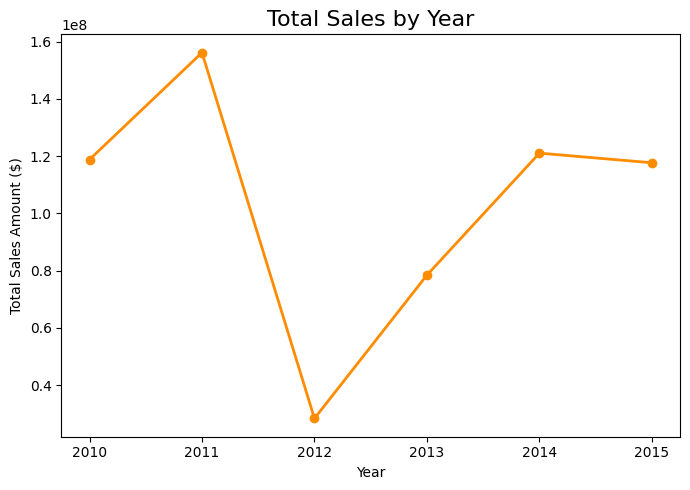

In [6]:
df_sales = dataframes['sales']
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'], errors='coerce')

yearly_sales = df_sales.groupby(df_sales['order_date'].dt.year)['total_amount'].sum().reset_index()
yearly_sales.columns = ['Year', 'Total Sales Amount']

plt.figure(figsize=(7, 5))
plt.plot(yearly_sales['Year'], yearly_sales['Total Sales Amount'], marker='o', color='darkorange', linewidth=2)
plt.title('Total Sales by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total Sales Amount ($)')
plt.tight_layout()
plt.show()


### Chart-2: Sales by country ###

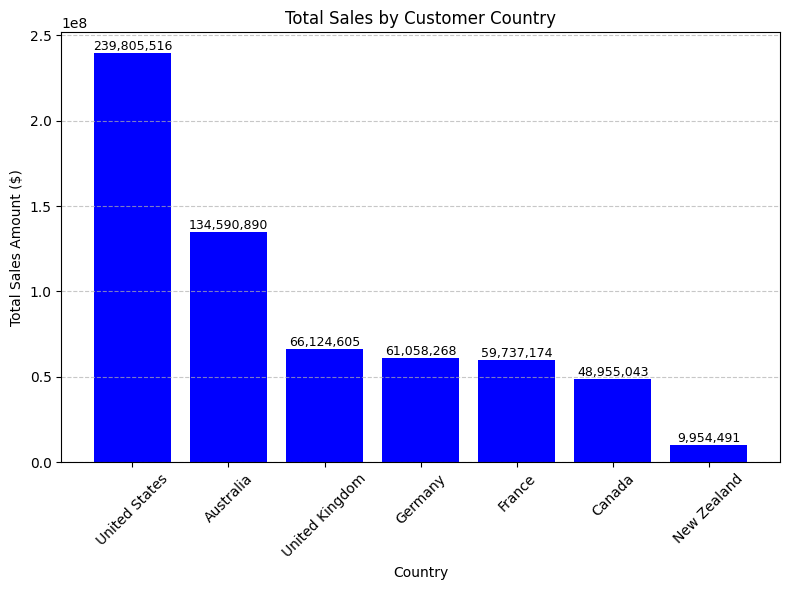

In [7]:
df_customers = dataframes['customers']
df_sales = dataframes['sales']

sales_with_customers = pd.merge(df_sales, df_customers, on='customer_key', how='left')

country_sales = sales_with_customers.groupby('country')['total_amount'].sum().reset_index()
country_sales = country_sales.sort_values(by='total_amount', ascending=False)

plt.figure(figsize=(8, 6))
bars = plt.bar(country_sales['country'], country_sales['total_amount'], color='blue')
plt.title('Total Sales by Customer Country', fontsize=12)
plt.xlabel('Country')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Chart-3: Product category wise analysis ###

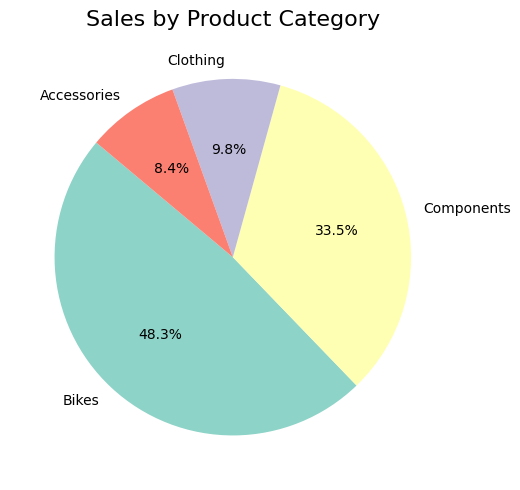

In [8]:
df_products = dataframes['products']
sales_products = pd.merge(df_sales, df_products, on='product_key', how='left')

category_sales = sales_products.groupby('category')['total_amount'].sum().reset_index()
category_sales = category_sales.sort_values(by='total_amount', ascending=False)

plt.figure(figsize=(6, 5))
plt.pie(
    category_sales['total_amount'],
    labels=category_sales['category'],
    autopct='%1.1f%%',  # show only percentage
    startangle=140,
    colors=plt.cm.Set3.colors
)
plt.title('Sales by Product Category', fontsize=16)
plt.tight_layout()
plt.show()


### Loading dataframes into database ###

In [48]:
for name,df in dataframes.items():
    try:
        df.to_sql(name=name, con=engine, if_exists='replace', index=False)
        print(f"✅ Uploaded table: {name}")
    except Exception as e:
        print(f"❌ Failed to upload {name}: {e}")

✅ Uploaded table: customers
✅ Uploaded table: products
✅ Uploaded table: sales
✅ Uploaded table: suppliers
